# 02 — Classical Baselines

Two baselines from the rubric:
1. **Majority class** — predict `activist` for every tweet (the more frequent class post-cleaning).
2. **TF-IDF + Logistic Regression** — the canonical bag-of-words classifier.

Predictions are saved per model to `results/predictions/` for the error-analysis notebook (`07`).

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from src.data import load_splits
from src.eval import evaluate, append_metrics, pretty_report, LABELS

FIG_DIR = PROJECT_ROOT / 'results' / 'figures' / 'baselines'
FIG_DIR.mkdir(parents=True, exist_ok=True)
PRED_DIR = PROJECT_ROOT / 'results' / 'predictions'
PRED_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110

In [2]:
train, val, test = load_splits()
X_train, y_train = train['clean_text'].values, train['stance'].values
X_val,   y_val   = val['clean_text'].values,   val['stance'].values
X_test,  y_test  = test['clean_text'].values,  test['stance'].values

print(f'train: {len(X_train):>6,}   val: {len(X_val):>6,}   test: {len(X_test):>6,}')

train: 74,297   val:  9,288   test:  9,288


In [3]:
def plot_confusion(cm, title, save_as):
    fig, ax = plt.subplots(figsize=(4.2, 3.8))
    sns.heatmap(
        cm, annot=True, fmt=',d', cmap='Blues',
        xticklabels=LABELS, yticklabels=LABELS, cbar=False, ax=ax,
    )
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(FIG_DIR / save_as, bbox_inches='tight')
    plt.show()

def save_predictions(model_name, y_true, y_pred, y_proba=None):
    df = pd.DataFrame({'y_true': y_true, 'y_pred': y_pred})
    if y_proba is not None:
        df['proba_sceptic'] = y_proba
    df.to_parquet(PRED_DIR / f'{model_name}.parquet', index=False)

## 1. Majority-class baseline

Majority class on train: 'activist'
              precision    recall  f1-score   support

    activist     0.5383    1.0000    0.6999      5000
     sceptic     0.0000    0.0000    0.0000      4288

    accuracy                         0.5383      9288
   macro avg     0.2692    0.5000    0.3499      9288
weighted avg     0.2898    0.5383    0.3768      9288



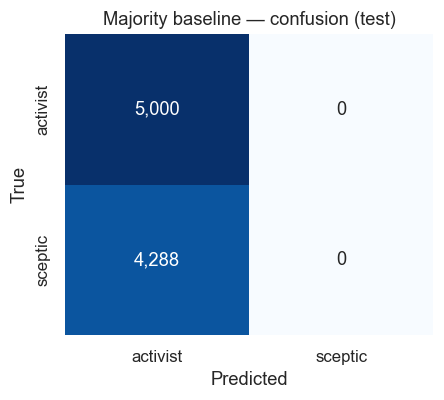

In [4]:
majority_label = pd.Series(y_train).mode().iloc[0]
print(f'Majority class on train: {majority_label!r}')

y_pred_majority = np.full_like(y_test, fill_value=majority_label, dtype=object)
metrics, cm = evaluate('majority', y_test, y_pred_majority)
print(pretty_report(y_test, y_pred_majority))
append_metrics(metrics)
save_predictions('majority', y_test, y_pred_majority)
plot_confusion(cm, 'Majority baseline — confusion (test)', 'cm_majority.png')

## 2. TF-IDF + Logistic Regression

In [5]:
tfidf_lr = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.95,
        sublinear_tf=True,
        max_features=200_000,
    )),
    ('clf', LogisticRegression(
        C=1.0, solver='liblinear', max_iter=1000, random_state=42,
    )),
])

t0 = time.time()
tfidf_lr.fit(X_train, y_train)
print(f'fit time: {time.time() - t0:.1f}s')

vocab_size = len(tfidf_lr.named_steps['tfidf'].vocabulary_)
print(f'vocab size: {vocab_size:,}')

fit time: 3.0s
vocab size: 91,318


val accuracy: 0.8917


              precision    recall  f1-score   support

    activist     0.8923    0.9062    0.8992      5000
     sceptic     0.8886    0.8724    0.8804      4288

    accuracy                         0.8906      9288
   macro avg     0.8904    0.8893    0.8898      9288
weighted avg     0.8906    0.8906    0.8905      9288



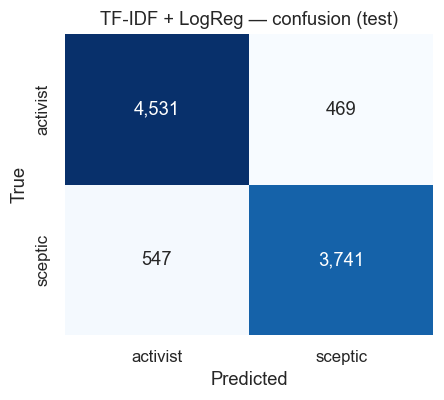

In [6]:
y_pred_val = tfidf_lr.predict(X_val)
val_acc = (y_pred_val == y_val).mean()
print(f'val accuracy: {val_acc:.4f}')

y_pred_test = tfidf_lr.predict(X_test)
y_proba_test = tfidf_lr.predict_proba(X_test)
sceptic_idx = list(tfidf_lr.classes_).index('sceptic')
y_proba_sceptic = y_proba_test[:, sceptic_idx]

metrics, cm = evaluate('tfidf_lr', y_test, y_pred_test, y_proba=y_proba_sceptic)
print(pretty_report(y_test, y_pred_test))
append_metrics(metrics)
save_predictions('tfidf_lr', y_test, y_pred_test, y_proba=y_proba_sceptic)
plot_confusion(cm, 'TF-IDF + LogReg — confusion (test)', 'cm_tfidf_lr.png')

### Most discriminative n-grams

Logistic-regression coefficients are directly interpretable — the largest negative coefficients point to **activist** features (because `activist` is class 0 alphabetically), the largest positive ones to **sceptic** features.

In [7]:
vec = tfidf_lr.named_steps['tfidf']
clf = tfidf_lr.named_steps['clf']
feature_names = np.array(vec.get_feature_names_out())
coefs = clf.coef_.ravel()
positive_class = clf.classes_[1]
negative_class = clf.classes_[0]

top_pos_idx = np.argsort(coefs)[-20:][::-1]
top_neg_idx = np.argsort(coefs)[:20]
top_terms = pd.DataFrame({
    f'{positive_class} (+)': feature_names[top_pos_idx],
    f'{positive_class} coef': coefs[top_pos_idx].round(3),
    f'{negative_class} (-)': feature_names[top_neg_idx],
    f'{negative_class} coef': coefs[top_neg_idx].round(3),
})
top_terms

,sceptic (+),sceptic coef,activist (-),activist coef
0,aqhiz3gab4ikq,10.933,2021,-6.963
1,hoax,6.604,to,-6.722
2,is is,5.997,action,-6.451
3,scam,5.777,join,-6.039
4,co2,5.172,for,-5.916
5,greta,4.945,our,-5.812
6,world farmers,4.750,future,-5.191
7,global warming,4.572,in,-4.958
8,money,4.449,justice,-4.648
9,they,4.400,communities,-4.633


In [8]:
# Persist the trained pipeline so we can use it as a feature in error analysis later
import joblib
MODEL_DIR = PROJECT_ROOT / 'results' / 'models'
MODEL_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(tfidf_lr, MODEL_DIR / 'tfidf_lr.joblib')
print(f'Saved to {MODEL_DIR / "tfidf_lr.joblib"}')

Saved to /Users/alexmusyoka/Desktop/NLP Labs/NLP_Project/results/models/tfidf_lr.joblib


## 3. Summary so far

In [9]:
results = pd.read_csv(PROJECT_ROOT / 'results' / 'metrics.csv')
results.round(4)

,model,accuracy,f1_macro,f1_weighted,precision_activist,recall_activist,f1_activist,precision_sceptic,recall_sceptic,f1_sceptic,roc_auc
0,majority,0.5383,0.3499,0.3768,0.5383,1.0000,0.6999,0.0000,0.0000,0.0000,NaN
1,tfidf_lr,0.8906,0.8898,0.8905,0.8923,0.9062,0.8992,0.8886,0.8724,0.8804,0.9581
